# LSTM Time Series Forecasting — Airline Passengers

Stacked LSTM with 12-month lag features, evaluated via RMSE.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
from IPython.display import Image, display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"
models_dir = project_root / "models"
results_dir = project_root / "results"
data_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Project root:", project_root)

Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.21.0
Project root: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting


## Section 1: Load Dataset

In [2]:
csv_path = data_dir / "airline_passengers.csv"
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded local file: {csv_path}")
else:
    df = pd.read_csv(url)
    # Normalize column names if they differ
    rename_map = {}
    cols_lower = {c.lower(): c for c in df.columns}
    if "month" in cols_lower and cols_lower["month"] != "Month":
        rename_map[cols_lower["month"]] = "Month"
    if "passengers" in cols_lower and cols_lower["passengers"] != "Passengers":
        rename_map[cols_lower["passengers"]] = "Passengers"
    # Common alternate: "International airline passengers: monthly totals in thousands"
    if len(df.columns) == 2 and "Passengers" not in df.columns:
        df.columns = ["Month", "Passengers"]
    elif rename_map:
        df = df.rename(columns=rename_map)
    df.to_csv(csv_path, index=False)
    print(f"Fetched from URL and saved to: {csv_path}")

# Ensure expected column names
if list(df.columns) != ["Month", "Passengers"]:
    if len(df.columns) == 2:
        df.columns = ["Month", "Passengers"]

print(df.head())
print("Shape:", df.shape)
assert df.shape == (144, 2), f"Expected (144, 2), got {df.shape}"
print("Confirmed shape is (144, 2).")

Fetched from URL and saved to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting/data/airline_passengers.csv
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Shape: (144, 2)
Confirmed shape is (144, 2).


## Section 2: Scale the Data

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(df[["Passengers"]].values.astype("float32").reshape(-1, 1))
print("Scaled data shape:", dataset.shape)
print("Scaled range: [{:.4f}, {:.4f}]".format(dataset.min(), dataset.max()))
print("First 5 scaled values:\n", dataset[:5].ravel())

Scaled data shape: (144, 1)
Scaled range: [0.0000, 1.0000]
First 5 scaled values:
 [0.01544401 0.02702703 0.05405405 0.04826255 0.03281853]


## Section 3: Create Lag Features (Sliding Window)

In [4]:
def create_dataset(dataset, lookback=12):
    """Sliding-window lag features: X[t] = dataset[t:t+lookback], y[t] = dataset[t+lookback]."""
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i : i + lookback, 0])
        y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(y)

LOOKBACK = 12
X, y = create_dataset(dataset, lookback=LOOKBACK)
print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (132, 12)
y.shape: (132,)


## Section 4: Train-Test Split and Reshape for LSTM

In [5]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape to [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], LOOKBACK, 1))
X_test = X_test.reshape((X_test.shape[0], LOOKBACK, 1))

print("Training Set:", X_train.shape, y_train.shape)
print("Testing Set:", X_test.shape, y_test.shape)

Training Set: (105, 12, 1) (105,)
Testing Set: (27, 12, 1) (27,)


## Section 5: Build and Train LSTM Model

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(LOOKBACK, 1)),
    keras.layers.LSTM(50, activation="relu", return_sequences=True),
    keras.layers.LSTM(50, activation="relu"),
    keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse")
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    verbose=0,
    callbacks=[early_stop],
)

epochs_run = len(history.history["loss"])
print(f"Training finished after {epochs_run} epochs (EarlyStopping patience=15).")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.6f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Training finished after 82 epochs (EarlyStopping patience=15).
Final train loss: 0.001222
Final val loss:   0.004007


## Section 6: Forecast and Evaluate with RMSE

In [7]:
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

train_rmse = sqrt(mean_squared_error(y_train_inv, train_pred_inv))
test_rmse = sqrt(mean_squared_error(y_test_inv, test_pred_inv))

print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE:  {test_rmse:.3f}")

Train RMSE: 19.978
Test RMSE:  24.556


## Section 7: Visualize Forecast

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting/results/forecast_vs_actual.png


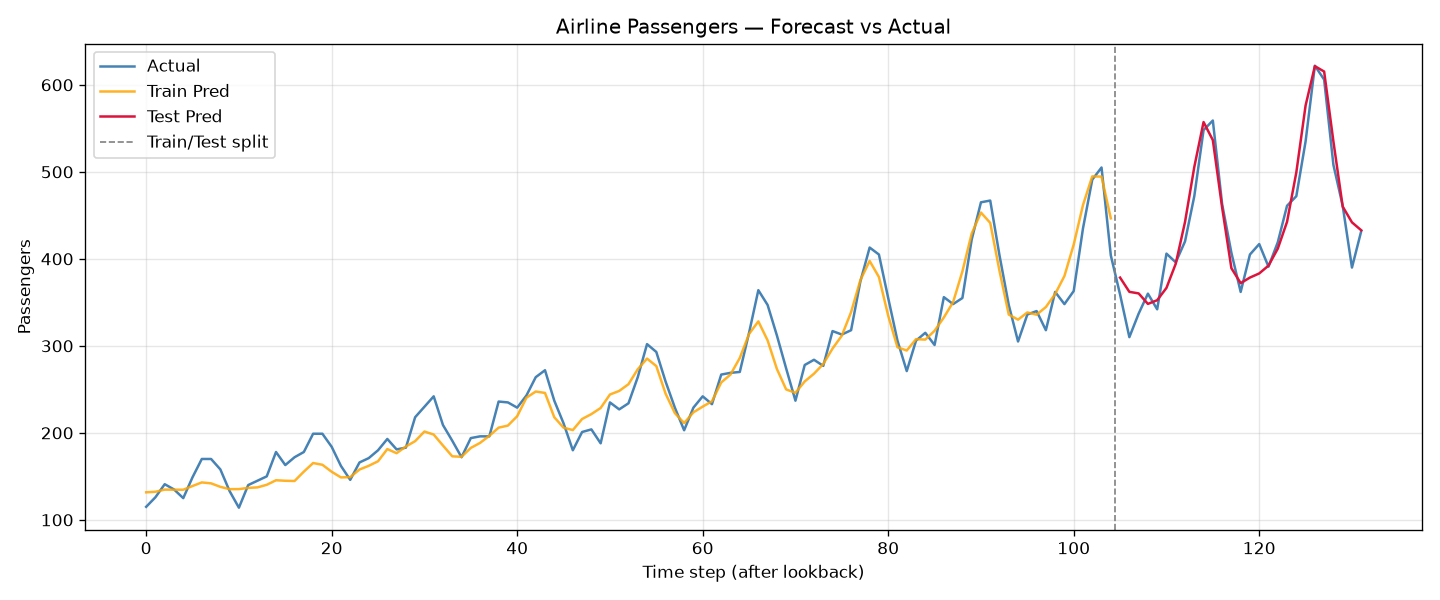

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting/results/loss_curve.png


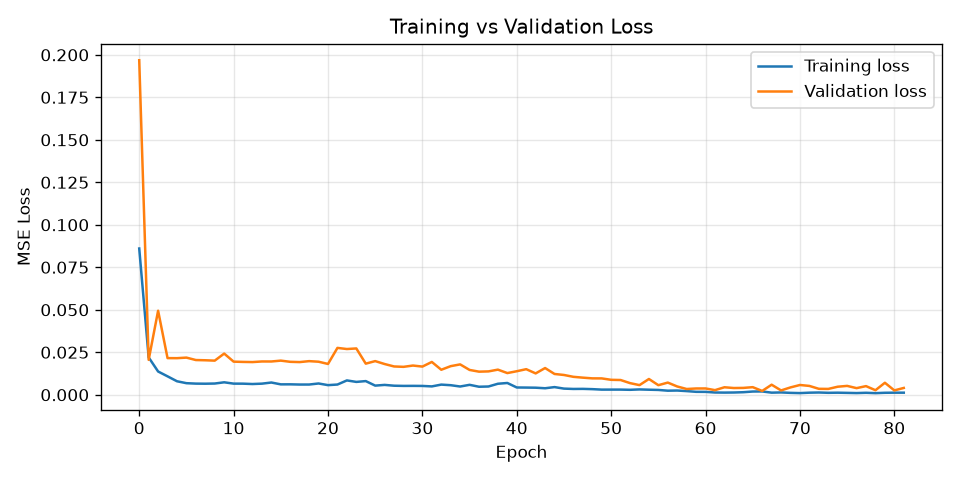

In [8]:
from IPython.display import Image, display

# --- Forecast vs Actual (single time-axis) ---
full_actual = np.concatenate([y_train_inv, y_test_inv]).ravel()
full_pred = np.concatenate([train_pred_inv, test_pred_inv]).ravel()
train_end = len(y_train_inv)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(full_actual, label="Actual", color="steelblue", linewidth=1.5)
ax.plot(range(train_end), train_pred_inv.ravel(), label="Train Pred", color="orange", alpha=0.85)
ax.plot(range(train_end, train_end + len(test_pred_inv)), test_pred_inv.ravel(),
        label="Test Pred", color="crimson", linewidth=1.5)
ax.axvline(train_end - 0.5, color="gray", linestyle="--", linewidth=1, label="Train/Test split")
ax.set_title("Airline Passengers — Forecast vs Actual")
ax.set_xlabel("Time step (after lookback)")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
forecast_path = results_dir / "forecast_vs_actual.png"
fig.tight_layout()
fig.savefig(forecast_path, dpi=120)
plt.close(fig)
print(f"Saved: {forecast_path}")
display(Image(filename=str(forecast_path)))

# --- Loss curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], label="Training loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
loss_path = results_dir / "loss_curve.png"
fig.tight_layout()
fig.savefig(loss_path, dpi=120)
plt.close(fig)
print(f"Saved: {loss_path}")
display(Image(filename=str(loss_path)))

## Section 8: Save Model

In [9]:
model_path = models_dir / "lstm_forecast.keras"
model.save(model_path)
print(f"Model saved to: {model_path}")
print("Data Scaled and Windowed")
print("LSTM Forecasting Model Trained")
print("Predictions Generated")
print("Business-Ready Forecast Produced")

Model saved to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting/models/lstm_forecast.keras
Data Scaled and Windowed
LSTM Forecasting Model Trained
Predictions Generated
Business-Ready Forecast Produced


## Section 9: Results Summary

In [10]:
metrics_df = pd.DataFrame({
    "Metric": ["RMSE"],
    "Training Set": [round(train_rmse, 3)],
    "Testing Set": [round(test_rmse, 3)],
})
metrics_path = results_dir / "forecast_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(metrics_df.to_string(index=False))

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 6/time-series-forecasting/results/forecast_metrics.csv

Metric  Training Set  Testing Set
  RMSE        19.978       24.556


### RMSE Summary

| Metric | Training Set | Testing Set |
| --- | --- | --- |
| RMSE | 19.978 | 24.556 |

### Checklist

- [x] Data Scaled and Windowed
- [x] LSTM Forecasting Model Trained
- [x] Predictions Generated
- [x] Business-Ready Forecast Produced
